# Phase 3: Data Visualization

First, we set up the environment with the necessary libraries:

In [2]:
# Libraries for data processing:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None) # To be able to see all columns from the data frames

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df_flights = pd.read_csv("clean-data/customer-flight-activity-clean.csv")
df_customers = pd.read_csv("clean-data/customer-loyal-history-clean.csv")
df_master = pd.read_csv("clean-data/merged-master-data-clean.csv")
df_merged_high_salaries = pd.read_csv("clean-data/merged-high-salaries-clean.csv")
df_flights_booked = pd.read_csv("clean-data/flights-booked-not-zero.csv")

### 1. How is the distribution of flights booked per month during the year?

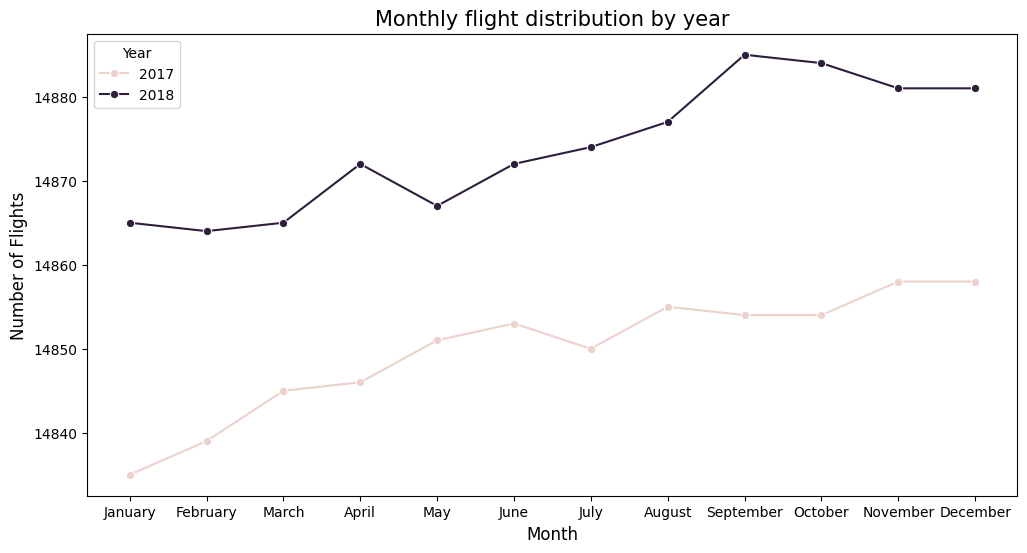

In [24]:
# We need to use a lineplot (tipically used for temopral variables)
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

# We make sure the 'month' column is categorical and ordered
df_master['month'] = pd.Categorical(df_master['month'], categories=month_order, ordered=True)

# We count flights per year and month
# We reset_index() to keep year and month as columns for plotting
df_counts = df_master.groupby(['year', 'month']).size().reset_index(name='flight_count')

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_counts, x='month', y='flight_count', hue='year', marker='o')

plt.title('Monthly flight distribution by year', fontsize=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Flights', fontsize=12)
plt.legend(title='Year')
plt.show();

ANSWER QUESTION 1:

The lineplot shows that the number of flights per month is higher in 2018 than in 2017. The difference is not huge but this indicates that the business is growing. 

The lineplot also shows a clear growth trend. For both, the year always start at their lowest point and show a steady climb as we head towards spring. 

This may give us some information that either customers tend to book their summer holidays by March/April or that the customers tend to buy last-minute for easter and summer holidays. 

After summer the flights booked per month remain quite stable. There was a small decrease by the end of the year in 2018 versus 2017.

### 2. Is there a relationship between flight distance and the points accumulated by customers?

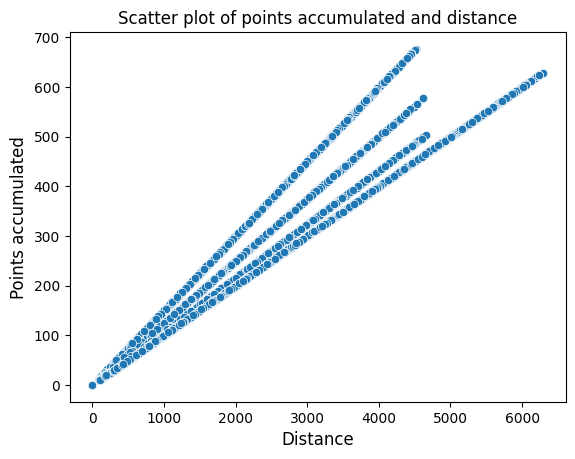

In [42]:
sns.scatterplot(data=df_master, x="distance", y="points_accumulated")
plt.title("Scatter plot of points accumulated and distance")
plt.ylabel('Points accumulated', fontsize=12)
plt.xlabel('Distance', fontsize=12);


ANSWER QUESTION 2:

As we saw in phase 2: There is a strong positive correlation between the points accumulated and the distance. 

The meaning of having a strong positive correlation is that as larger is the distance, more points will be accumulated. 

In addition to use a scatter plot to assess the correlation with these two values, we could also have calculated the correlation coefficient or have represented the heatmap as done in phase 2. 

In summary, the distance is a strong factor to accumulate points in this airline. 

### 3. What is the distribution of customers by province or state?

In [72]:
df_count_province = df_customers["province"].value_counts().reset_index()
df_count_province
# We create the data frame to do a pie with matplotlib later:

,province,count
0,Ontario,4758
1,British Columbia,3860
2,Quebec,2956
3,Alberta,862
4,Manitoba,601
5,New Brunswick,567
6,Nova Scotia,441
7,Saskatchewan,343
8,Newfoundland,233
9,Yukon,98


''

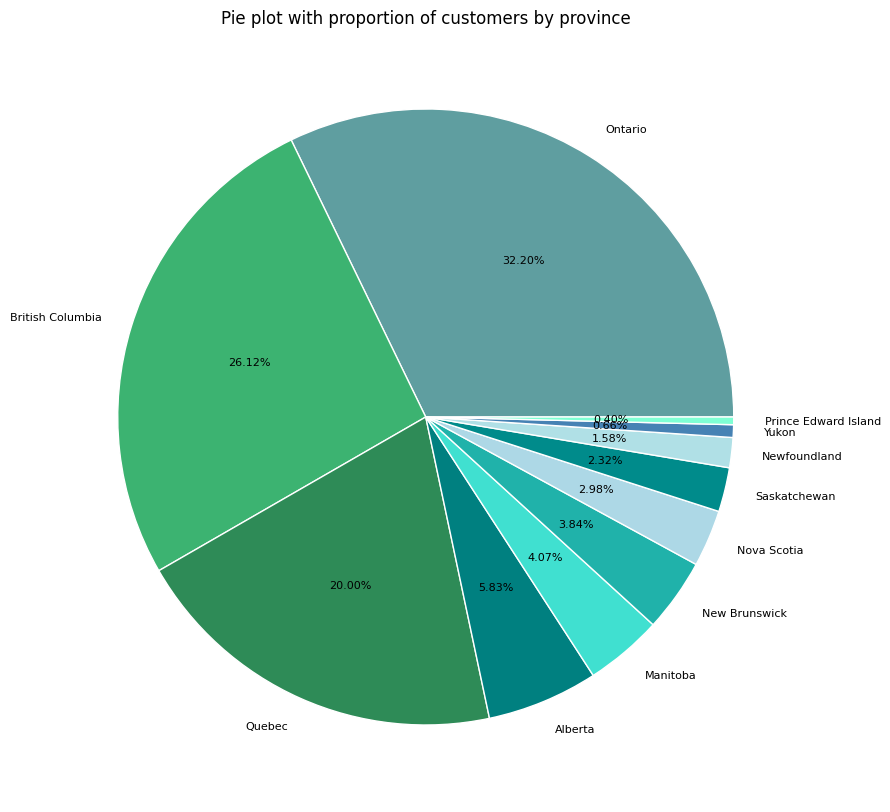

In [73]:
colors = ["cadetblue", "mediumseagreen", "seagreen", "teal", "turquoise", "lightseagreen", "lightblue", "darkcyan", "powderblue", "steelblue", "aquamarine"]
plt.figure(figsize=(17,10))
plt.pie(data=df_count_province, x="count", labels="province", colors=colors, autopct="%.2f%%", textprops={"fontsize": 8},wedgeprops={'edgecolor': 'white', 'linewidth': 1})
plt.title("Pie plot with proportion of customers by province")
;

ANSWER QUESTION 3:

We represent the proportion of customers by province with a pie (it could have been done with a countplot as well with the percentage on the y axis).

Roughly 80% of the customers are either from Quebe, British Columbia or Ontario.

Canada is a big country with most of the population concentrated in both coasts (east and west). The results from the pie were expected since these are the provinces with more population. The rest of the provinces are more rural areas with a less population density.

### 4. How does the average salary compare across the different educational levels of the customers?

In [70]:
mean_salary = round(df_customers["salary"].mean(),2)
median_salary = round(df_customers["salary"].median(),2)

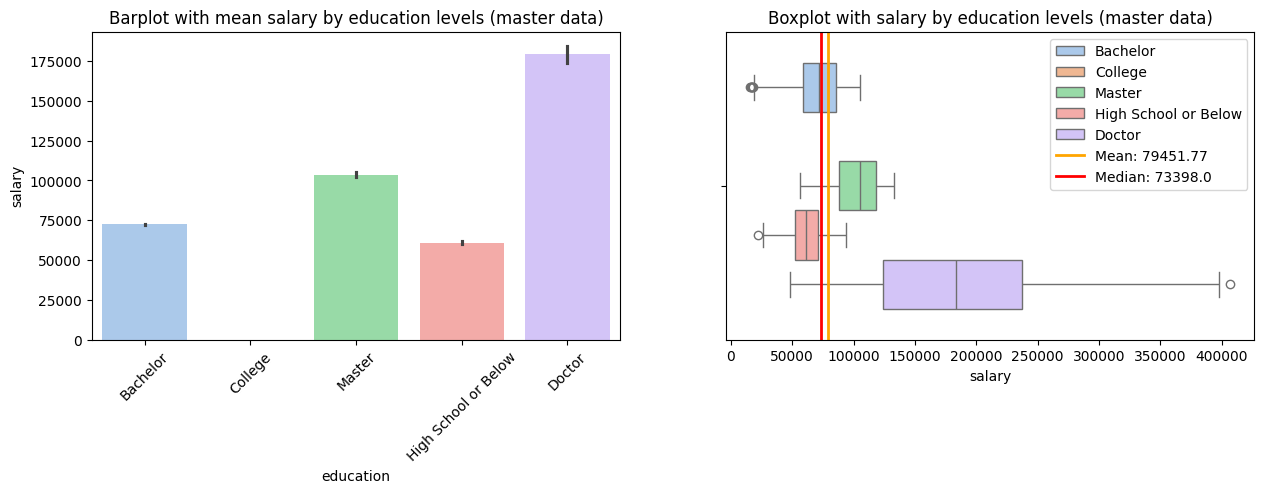

In [71]:
fig, axes = plt.subplots(ncols=2,nrows=1, figsize=(15,4)) 

sns.barplot(data=df_customers, x="education", y = "salary", ax=axes[0],hue="education",palette="pastel"); # barplot in position 0. 

sns.boxplot(data=df_customers, x="salary",ax=axes[1], hue="education",palette="pastel") # boxplot in position 1. 
axes[0].set_title("Barplot with mean salary by education levels (master data)")
axes[0].tick_params(axis="x", rotation=45)
axes[1].axvline(mean_salary, color = "orange", linestyle = "-", linewidth = 2, label = f"Mean: {mean_salary}")
axes[1].axvline(median_salary, color = "red", linestyle = "-", linewidth = 2, label = f"Median: {median_salary}")
axes[1].legend()
axes[1].set_title("Boxplot with salary by education levels (master data)");

ANSWER QUESTION 4:

We can clearly see that the average salary (around 175000) for doctors is significantly higher than the other education levels. Followed by the master holders, bachelor and the customers with the lowest earnings are the ones with high school or below. We have no values under college.

This was already identified in the phase 1 and 2. 

The graph on the left is a barplot showing the mean salary on the y axis and the different education levels on the x axis. 

The graph on the right hand side is a boxplot and it gives us a bit more information than the barplot. The line in the middle of the boxes is representing the quartile 50% which is the median. We can clearly see that the median of doctor's salaries is significantly higher than the general mean. 

These higher salaries are influencing the general mean, which is higher than the median.

We can also see that the salaries on the education levels: bachelor, degree and high school or below are much narrower than the doctor's one. This means that salaries in these group are more "condensed" and less dispersive than the doctors' salaries.


### 5. What is the proportion of customers with different types of loyalty cards?

In [66]:
df_count_cards = df_customers["loyalty_card"].value_counts().reset_index()
df_count_cards

,loyalty_card,count
0,Star,6880
1,Nova,4959
2,Aurora,2939


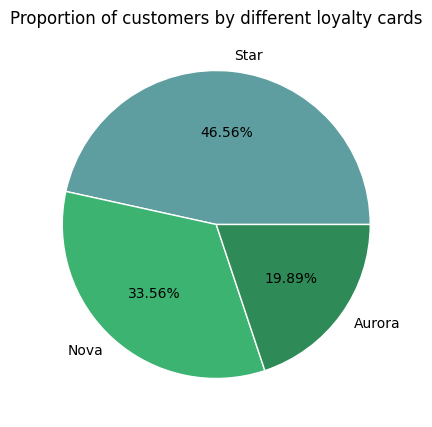

In [67]:
colors = ["cadetblue", "mediumseagreen", "seagreen"]
plt.figure(figsize=(10,5))
plt.pie(data=df_count_cards, x="count", labels="loyalty_card", colors=colors, autopct="%.2f%%", textprops={"fontsize": 10},wedgeprops={'edgecolor': 'white', 'linewidth': 1})
plt.title("Proportion of customers by different loyalty cards");

ANSWER QUESTION 5:

xxxxx


### 6. How are customers distributed according to their marital status and gender?

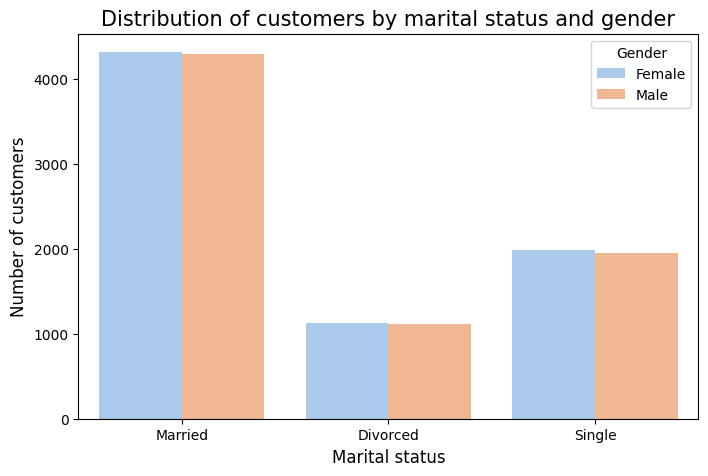

In [75]:
plt.figure(figsize=(8,5))

sns.countplot(data=df_customers, x='marital_status', hue='gender', palette='pastel')

plt.title('Distribution of customers by marital status and gender', fontsize=15)
plt.xlabel('Marital status', fontsize=12)
plt.ylabel('Number of customers', fontsize=12)
plt.legend(title='Gender');

ANSWER QUESTION 6:

The most commont marital status among the customers is married, followed by single and divorced.

Both bars, male and female, are almost the same height accross the different marital status.



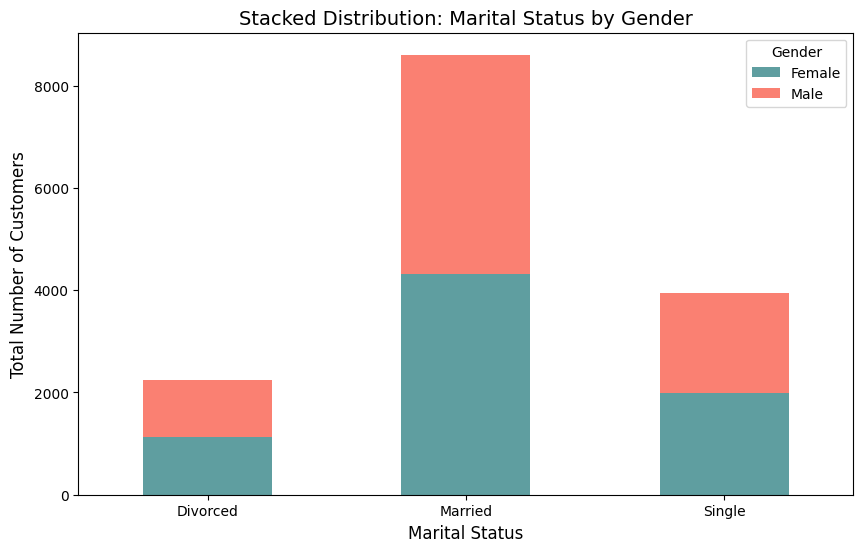

In [76]:

# 1. Create a frequency table (Crosstab)
# This counts how many Males/Females are in each Marital Status
status_gender_counts = pd.crosstab(df_customers['marital_status'], df_customers['gender'])

# 2. Plot the stacked bar chart
status_gender_counts.plot(kind='bar', stacked=True, figsize=(10, 6), color=['cadetblue', 'salmon'])

# 3. Add labels and title
plt.title('Stacked Distribution: Marital Status by Gender', fontsize=14)
plt.xlabel('Marital Status', fontsize=12)
plt.ylabel('Total Number of Customers', fontsize=12)
plt.xticks(rotation=0) # Keeps labels horizontal
plt.legend(title='Gender')

plt.show()